In [88]:
# Célula 0 — Instalar bibliotecas necessárias
!pip install pandas numpy matplotlib scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# Célula 1 — Todos os imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [90]:
# Célula 2 — Carregar dados
df_srv = pd.read_csv("servidores_ti.csv")
print(f"Dataset original: {df_srv.shape}")
df_srv.head()

Dataset original: (500, 7)


,servidor_id,tipo_rede,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos,status_alerta
0,SRV-001,AWS,60.13,67.01,25.31,5.34,1
1,SRV-002,On-Premise,83.14,55.69,23.79,0.60,0
2,SRV-003,Azure,69.26,67.09,2.00,0.99,1
3,SRV-004,Azure,46.35,73.30,18.27,0.33,1
4,SRV-005,AWS,41.52,69.85,4.07,1.42,0


In [91]:
# Verificação inicial: tipos de dados 
print(df_srv.dtypes)

servidor_id                  str
tipo_rede                    str
uso_cpu                  float64
uso_memoria              float64
latencia_rede_ms         float64
taxa_pacotes_perdidos    float64
status_alerta              int64
dtype: object


In [92]:
# Estimadores pontuais: média (X̄) e variância amostral (s²) com ddof=1 (não-viesada)
variaveis = ["uso_cpu", "latencia_rede_ms"]
resumo = pd.DataFrame({
    "media": df_srv
    [variaveis].mean(),
    "variancia": df_srv[variaveis].var(ddof=1),
    "desvio_padrao": df_srv[variaveis].std(ddof=1),
    "n": df_srv[variaveis].count()
})
resumo


,media,variancia,desvio_padrao,n
uso_cpu,55.11006,227.791307,15.092757,500
latencia_rede_ms,24.91934,559.758393,23.659214,500


In [93]:
# Intervalo de Confiança de 95% para a média verdadeira de uso_cpu
# Como o desvio-padrão populacional (sigma) é desconhecido e é estimado a partir da amostra,
# utiliza-se a distribuição t de Student com (n-1) graus de liberdade.
n = df_srv["uso_cpu"].count()
media_cpu = df_srv["uso_cpu"].mean()
desvio_cpu = df_srv["uso_cpu"].std(ddof=1)
erro_padrao = desvio_cpu / np.sqrt(n)

confianca = 0.95
alpha = 1 - confianca
t_critico = stats.t.ppf(1 - alpha/2, df=n-1)
margem_erro = t_critico * erro_padrao

ic_inferior = media_cpu - margem_erro
ic_superior = media_cpu + margem_erro

print(f"n = {n}")
print(f"Média amostral (X̄) = {media_cpu:.3f}%")
print(f"Desvio padrão amostral (s) = {desvio_cpu:.3f}")
print(f"Erro padrão (s/√n) = {erro_padrao:.4f}")
print(f"t crítico (gl={n-1}, 95%) = {t_critico:.4f}")
print(f"Margem de erro = {margem_erro:.4f}")
print(f"IC 95% para a média de uso_cpu: [{ic_inferior:.2f}% , {ic_superior:.2f}%]")


n = 500
Média amostral (X̄) = 55.110%
Desvio padrão amostral (s) = 15.093
Erro padrão (s/√n) = 0.6750
t crítico (gl=499, 95%) = 1.9647
Margem de erro = 1.3261
IC 95% para a média de uso_cpu: [53.78% , 56.44%]


parte 2

In [94]:
# Tabela de contingência: tipo_rede x status_alerta
tabela_contingencia = pd.crosstab(df_srv["tipo_rede"], df_srv["status_alerta"],
                                   rownames=["tipo_rede"], colnames=["status_alerta"])
tabela_contingencia.columns = ["Saudável (0)", "Falha Iminente (1)"]
tabela_contingencia


,Saudável (0),Falha Iminente (1)
tipo_rede,,
AWS,169,38
Azure,133,29
On-Premise,106,25


In [95]:
# Teste Qui-Quadrado de Independência
chi2_stat, p_valor, graus_liberdade, freq_esperada = stats.chi2_contingency(tabela_contingencia)

print(f"Estatística Qui-Quadrado (χ²) = {chi2_stat:.4f}")
print(f"Graus de liberdade = {graus_liberdade}")
print(f"p-valor = {p_valor:.4f}")
print("\nFrequências esperadas sob H0 (independência):")
print(pd.DataFrame(freq_esperada,
                    index=tabela_contingencia.index,
                    columns=tabela_contingencia.columns).round(2))

alpha = 0.05
if p_valor < alpha:
    print(f"\nComo p-valor ({p_valor:.4f}) < α ({alpha}), REJEITAMOS H0.")
else:
    print(f"\nComo p-valor ({p_valor:.4f}) >= α ({alpha}), NÃO rejeitamos H0.")


Estatística Qui-Quadrado (χ²) = 0.0679
Graus de liberdade = 2
p-valor = 0.9666

Frequências esperadas sob H0 (independência):
            Saudável (0)  Falha Iminente (1)
tipo_rede                                   
AWS               168.91               38.09
Azure             132.19               29.81
On-Premise        106.90               24.10

Como p-valor (0.9666) >= α (0.05), NÃO rejeitamos H0.


parte 3

In [96]:
# Seleção das variáveis quantitativas e padronização
colunas_quantitativas = ["uso_cpu", "uso_memoria", "latencia_rede_ms", "taxa_pacotes_perdidos"]
X = df_srv[colunas_quantitativas].values

scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

print("Média após padronização (deve ser ~0):", X_padronizado.mean(axis=0).round(3))
print("Desvio padrão após padronização (deve ser ~1):", X_padronizado.std(axis=0).round(3))


Média após padronização (deve ser ~0): [ 0.  0. -0.  0.]
Desvio padrão após padronização (deve ser ~1): [1. 1. 1. 1.]


In [97]:
# Aplicação do PCA com 2 componentes principais
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_padronizado)

df_pca = pd.DataFrame(componentes_principais, columns=["PC1", "PC2"])
df_pca["status_alerta"] = df_srv["status_alerta"].values

variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

print("Variância explicada por componente:")
for i, (v, vac) in enumerate(zip(variancia_explicada, variancia_acumulada), start=1):
    print(f"  PC{i}: {v*100:.2f}% (acumulada: {vac*100:.2f}%)")


Variância explicada por componente:
  PC1: 26.58% (acumulada: 26.58%)
  PC2: 26.02% (acumulada: 52.60%)


In [98]:
# Cargas fatoriais (loadings): contribuição de cada variável original para PC1 e PC2
cargas = pd.DataFrame(pca.components_, columns=colunas_quantitativas, index=["PC1", "PC2"])
cargas.round(3)


,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos
PC1,-0.097,0.261,0.700,-0.658
PC2,0.704,0.660,0.084,0.248


parte 4

In [99]:
# Definição de X (features = componentes principais) e y (alvo)
X_modelo = df_pca[["PC1", "PC2"]].values
y_modelo = df_pca["status_alerta"].values

# Divisão treino (70%) / teste (30%) com semente fixa para reprodutibilidade
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_modelo, y_modelo, test_size=0.30, random_state=42, stratify=y_modelo
)

print(f"Tamanho do treino: {X_treino.shape[0]} amostras")
print(f"Tamanho do teste:  {X_teste.shape[0]} amostras")
print(f"Proporção de falhas (classe 1) no treino: {y_treino.mean()*100:.1f}%")
print(f"Proporção de falhas (classe 1) no teste:  {y_teste.mean()*100:.1f}%")


Tamanho do treino: 350 amostras
Tamanho do teste:  150 amostras
Proporção de falhas (classe 1) no treino: 18.3%
Proporção de falhas (classe 1) no teste:  18.7%


In [100]:
# Instanciação e treinamento do classificador KNN com K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)

y_previsto = knn.predict(X_teste)


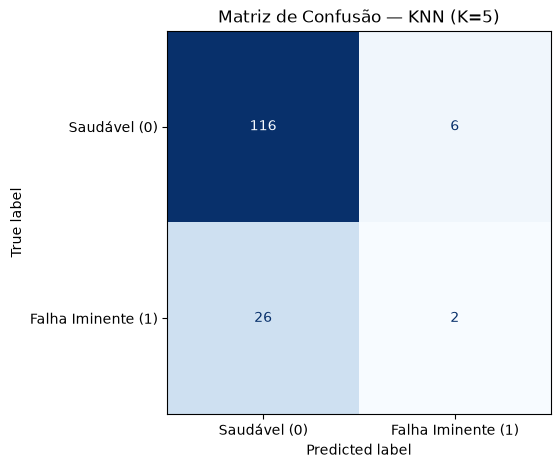

[[116   6]
 [ 26   2]]


In [101]:
# Matriz de confusão
matriz_confusao = confusion_matrix(y_teste, y_previsto)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                               display_labels=["Saudável (0)", "Falha Iminente (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — KNN (K=5)")
plt.tight_layout()
plt.show()

print(matriz_confusao)


In [102]:
# Relatório de classificação completo (precisão, revocação, F1-score)
relatorio = classification_report(y_teste, y_previsto,
                                   target_names=["Saudável (0)", "Falha Iminente (1)"],
                                   digits=3)
print(relatorio)


                    precision    recall  f1-score   support

      Saudável (0)      0.817     0.951     0.879       122
Falha Iminente (1)      0.250     0.071     0.111        28

          accuracy                          0.787       150
         macro avg      0.533     0.511     0.495       150
      weighted avg      0.711     0.787     0.735       150

